In [12]:
from amplpy import AMPL, ampl_notebook


In [45]:
ampl=ampl_notebook(
    module=['gurobi','highs'],
    license_uuid='fb5195d0-ea81-4d48-86fb-5c8008b32fd0'
)

Licensed to AMPL Community Edition License for <ahaastrup245335@stu.ui.edu.ng>.


In [46]:
%%writefile Maintenance_Optimization.mod


# SETS

set MACHINES;


# PARAMETERS
param p{MACHINES} >= 0, <= 1; # Failure probability from Machine learning model
param Cm >= 0; # Cost of performing maintenance
param Cf >= 0; # Cost incurred if machine fails
param K >= 0, integer; # Maximum number of machines that can be maintained

# DECISION VARIABLES

var x{MACHINES} binary; # 1 if machine i is selected for maintenance, 0 otherwise

# OBJECTIVE FUNCTION

minimize Total_Cost:
    sum{i in MACHINES} (
        Cm * x[i] + Cf * p[i] * (1 - x[i])
    );


# CONSTRAINTS

subject to Maintenance_Limit:
    sum{i in MACHINES} x[i] <= K; # Limit on number of machines that can be maintained



Overwriting Maintenance_Optimization.mod


In [49]:
from amplpy import AMPL
import pandas as pd


df = pd.read_csv("probability.csv")

ampl = AMPL()
ampl.read("Maintenance_Optimization.mod")


machines = df["machine"].tolist()

ampl.set["MACHINES"] = machines

p_dict = dict(zip(df["machine"], df["p"]))

ampl.param["p"] = p_dict

# Parameters
ampl.param["Cm"] = 50
ampl.param["Cf"] = 200
ampl.param["K"] = 2


# Display the model that has been built
ampl.eval('show;')
ampl.eval('expand;')




parameters:   Cf   Cm   K   p

set:   MACHINES

variable:   x

constraint:   Maintenance_Limit

objective:   Total_Cost
minimize Total_Cost:
	48.6446*x[1] + 49.9848*x[2] + 49.986*x[3] + 49.9884*x[4] + 49.9965*x[5]
	 + 49.9844*x[6] + 49.9829*x[7] + 49.993*x[8] + 41.1196*x[9] + 
	49.9872*x[10] + 47.7733*x[11] + 49.9897*x[12] + 49.4783*x[13] + 
	49.9928*x[14] + 49.8997*x[15] + 49.9527*x[16] + 49.9279*x[17] + 
	49.9948*x[18] + 49.9693*x[19] + 49.9909*x[20] + 49.9887*x[21] + 
	49.932*x[22] + 49.9931*x[23] + 49.9953*x[24] + 49.9807*x[25] + 
	49.9978*x[26] + 49.9918*x[27] + 49.9834*x[28] + 49.95*x[29] + 
	49.9846*x[30] + 49.9132*x[31] + 49.9881*x[32] + 48.4232*x[33] + 
	49.9687*x[34] + 49.8585*x[35] + 49.992*x[36] + 49.8201*x[37] + 
	49.9752*x[38] + 49.9961*x[39] + 49.9933*x[40] + 49.9765*x[41] + 
	49.9964*x[42] + 49.9811*x[43] + 49.9937*x[44] + 38.5512*x[45] + 
	45.3501*x[46] + 49.9567*x[47] - 133.041*x[48] + 49.9009*x[49] + 
	49.9526*x[50] + 49.3079*x[51] + 49.9932*x[52] + 49.9911*x[53] + 

In [52]:
#Solving


ampl.option["solver"] = "highs"
ampl.solve()


ampl.option["solver"] = "gurobi"
ampl.solve()

HiGHS 1.8.1:HiGHS 1.8.1: optimal solution; objective 11773.16733
1 simplex iterations
1 branching nodes
Gurobi 13.0.1:Gurobi 13.0.1: optimal solution; objective 11773.16733
0 simplex iterations


In [65]:

# EXTRACT RESULTS

x_df = ampl.getVariable("x").getValues().toPandas()
total_cost = ampl.getObjective("Total_Cost").value()
print(x_df)


      x.val
1         0
2         0
3         0
4         0
5         0
...     ...
1996      0
1997      0
1998      0
1999      0
2000      0

[2000 rows x 1 columns]


With the available crew, maintenance should be carried out on;
      Machine  Decision
633       633         1
1674     1674         1


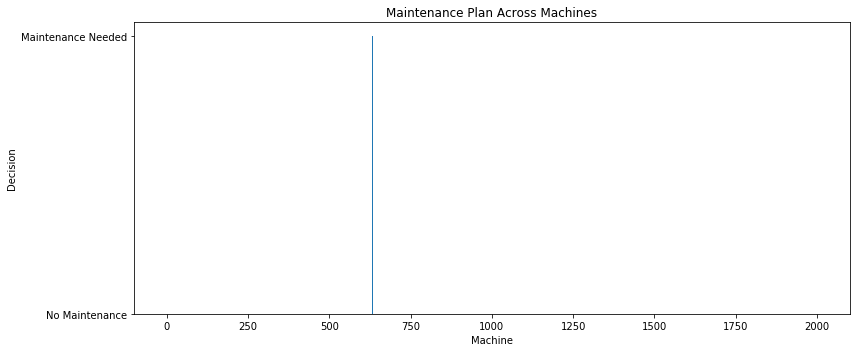

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the single column
values = x_df.iloc[:, 0]

# Create machine labels 
machines = range(1, len(values) + 1)

plot_df = pd.DataFrame({
    "Machine": machines,
    "Decision": values
})


maintenance_machines = plot_df[plot_df["Decision"] == 1]

print('With the available crew, maintenance should be carried out on;')
print(maintenance_machines)


plt.figure(figsize=(12, 5))
plt.bar(plot_df["Machine"], plot_df["Decision"])

plt.yticks([0, 1], ["No Maintenance", "Maintenance Needed"])
plt.xlabel("Machine")
plt.ylabel("Decision")
plt.title("Maintenance Plan Across Machines")

plt.tight_layout()
plt.show()